<a href="https://colab.research.google.com/github/krithimani07-crypto/CODSOFT/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
# Step 2: Load Dataset
df = pd.read_csv("fraudTest.csv", engine='python', on_bad_lines='skip')

In [7]:
# Step 3: View Dataset
print(df.shape)
print(df.head())
print(df.columns)

(46670, 23)
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      F             3638 Marsh Union  .

In [8]:
# Step 4: Check fraud vs normal
print(df['is_fraud'].value_counts())

is_fraud
0.0    46474
1.0      195
Name: count, dtype: int64


In [10]:
# Step 5: Check missing values
print(df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   1
street                   1
city                     1
state                    1
zip                      1
lat                      1
long                     1
city_pop                 1
job                      1
dob                      1
trans_num                1
unix_time                1
merch_lat                1
merch_long               1
is_fraud                 1
dtype: int64


In [11]:
# Step 6: Drop unwanted columns
df = df.drop(['Unnamed: 0','trans_date_trans_time','cc_num','first','last','street','city','state','zip','dob','trans_num'], axis=1, errors='ignore')

In [12]:
# Step 7: Convert categorical to numerical
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [13]:
# Step 8: Define X and y
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [14]:
# Step 9: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Step 10: Clean NaN and infinite values
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)
y_train = pd.to_numeric(y_train, errors='coerce').fillna(0)
y_test = pd.to_numeric(y_test, errors='coerce').fillna(0)

In [16]:
# Step 11: Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [17]:
# Step 12: Make predictions
y_pred = model.predict(X_test)

In [18]:
# Step 13: Evaluate model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9284
         1.0       1.00      0.44      0.61        50

    accuracy                           1.00      9334
   macro avg       1.00      0.72      0.80      9334
weighted avg       1.00      1.00      1.00      9334



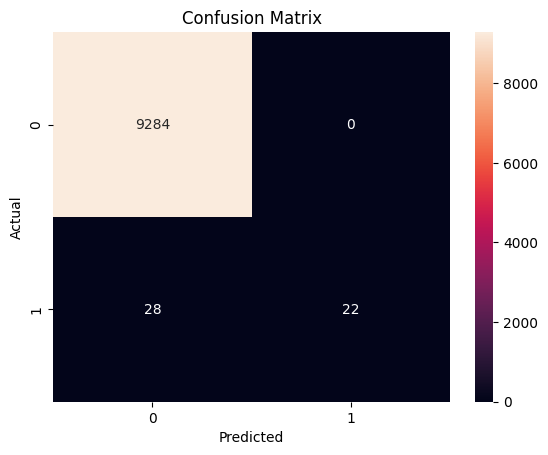

In [19]:
# Step 14: Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
# Step 15: Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9970002142704093


In [23]:
# Step 16: Detailed performance metrics
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 1.0
Recall: 0.44
F1 Score: 0.6111111111111112


In [24]:
# Step 17: Compare actual vs predicted
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(20))

    Actual  Predicted
0      0.0        0.0
1      0.0        0.0
2      0.0        0.0
3      0.0        0.0
4      0.0        0.0
5      0.0        0.0
6      0.0        0.0
7      0.0        0.0
8      0.0        0.0
9      0.0        0.0
10     0.0        0.0
11     0.0        0.0
12     0.0        0.0
13     0.0        0.0
14     1.0        1.0
15     0.0        0.0
16     0.0        0.0
17     0.0        0.0
18     0.0        0.0
19     0.0        0.0


In [25]:
# Step 18: Show only predicted fraud cases
fraud_cases = results[results['Predicted'] == 1]
print(fraud_cases.head())

      Actual  Predicted
14       1.0        1.0
801      1.0        1.0
1146     1.0        1.0
1542     1.0        1.0
2142     1.0        1.0


In [26]:
# Step 19: Save trained model
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [27]:
# Step 20: Show important features used by the model
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

       Feature  Importance
2          amt    0.292027
8    unix_time    0.109512
1     category    0.101165
10  merch_long    0.081685
9    merch_lat    0.073859
5         long    0.072163
4          lat    0.071596
6     city_pop    0.070991
7          job    0.062787
0     merchant    0.057770


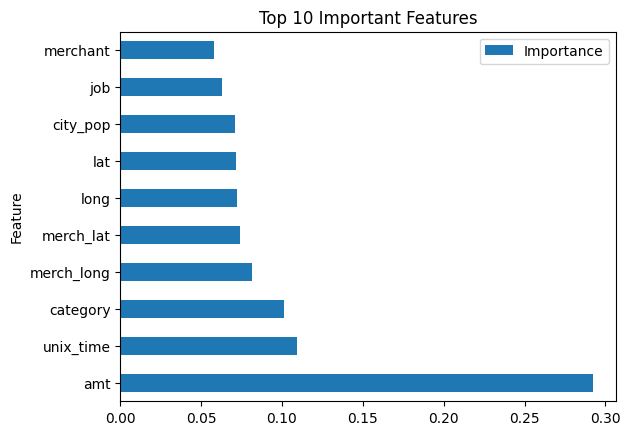

In [28]:
# Step 21: Visualize feature importance
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Important Features")
plt.show()

In [29]:
# Step 22: Predict a single transaction (example)
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0.]


In [32]:
# Step 23: Create final output dataframe
final_output = X_test.copy()

final_output['Actual'] = y_test.values
final_output['Predicted'] = y_pred

In [33]:
# Step 24: Convert 0/1 into readable labels
final_output['Actual_Label'] = final_output['Actual'].map({0: 'Normal', 1: 'Fraud'})
final_output['Predicted_Label'] = final_output['Predicted'].map({0: 'Normal', 1: 'Fraud'})

In [34]:
# Step 25: Display output
print(final_output[['Actual_Label', 'Predicted_Label']].head(20))

      Actual_Label Predicted_Label
8721        Normal          Normal
22071       Normal          Normal
21345       Normal          Normal
25349       Normal          Normal
2893        Normal          Normal
15334       Normal          Normal
42203       Normal          Normal
21877       Normal          Normal
32927       Normal          Normal
29916       Normal          Normal
24937       Normal          Normal
16886       Normal          Normal
19509       Normal          Normal
13664       Normal          Normal
42537        Fraud           Fraud
31429       Normal          Normal
35658       Normal          Normal
30963       Normal          Normal
16269       Normal          Normal
35684       Normal          Normal


In [35]:
# Step 26: Separate fraud and normal transactions

fraud_data = final_output[final_output['Predicted'] == 1]
normal_data = final_output[final_output['Predicted'] == 0]

print("Fraud Transactions:")
print(fraud_data.head())

print("Normal Transactions:")
print(normal_data.head())

Fraud Transactions:
       merchant  category      amt  gender      lat      long  city_pop  job  \
42537        96         3    10.84       0  31.9240 -105.2099     579.0  226   
18572        27        11  1134.41       0  34.0480  -85.9246   67082.0  326   
21937       175        11  1142.66       1  41.0695  -81.5488  272134.0   55   
22427       352         4   291.15       0  38.2507  -85.7476  736284.0  168   
1784        238        11  1077.69       1  30.4590  -90.9027   71335.0  214   

          unix_time  merch_lat  merch_long  Actual  Predicted Actual_Label  \
42537  1.373082e+09  31.577259 -105.629058     1.0        1.0        Fraud   
18572  1.372376e+09  33.114693  -85.837443     1.0        1.0        Fraud   
21937  1.372462e+09  41.894724  -81.866035     1.0        1.0        Fraud   
22427  1.372474e+09  37.790394  -85.506713     1.0        1.0        Fraud   
1784   1.371854e+09  31.204974  -90.261595     1.0        1.0        Fraud   

      Predicted_Label  
42537 

In [36]:
# Step 27: Save outputs to files

fraud_data.to_csv("fraud_transactions.csv", index=False)
normal_data.to_csv("normal_transactions.csv", index=False)

In [37]:
# Step 28: Show only fraud cases clearly
print(final_output[final_output['Predicted_Label'] == 'Fraud'][['Actual_Label','Predicted_Label']])

      Actual_Label Predicted_Label
42537        Fraud           Fraud
18572        Fraud           Fraud
21937        Fraud           Fraud
22427        Fraud           Fraud
1784         Fraud           Fraud
26607        Fraud           Fraud
42139        Fraud           Fraud
23015        Fraud           Fraud
10036        Fraud           Fraud
26161        Fraud           Fraud
22379        Fraud           Fraud
1956         Fraud           Fraud
16196        Fraud           Fraud
36126        Fraud           Fraud
22087        Fraud           Fraud
34001        Fraud           Fraud
11710        Fraud           Fraud
30007        Fraud           Fraud
39021        Fraud           Fraud
11799        Fraud           Fraud
1968         Fraud           Fraud
14064        Fraud           Fraud


In [38]:
# Step 29: End of program
print("Program executed successfully. Credit Card Fraud Detection Completed.")

Program executed successfully. Credit Card Fraud Detection Completed.
